# マナビDXクエスト2026参加者向け練習用機器学習コンペ サンプル ノートブック

## ライブラリをインポート

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as LR
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error as MSE

## コンペ配布データ読み込み

### 学習用データ読み込み

In [2]:
train_df = pd.read_csv(f"./data/train.csv")

In [3]:
train_df

,id,temperature,sunshine_h,humidity,ice_sales
0,1,23.2,6.2,56.5,324
1,2,31.3,5.2,69.0,640
2,3,28.2,3.9,80.6,306
3,4,26.4,6.9,75.6,477
4,5,20.2,6.1,78.2,267
...,...,...,...,...,...
495,496,22.9,2.5,73.4,77
496,497,26.2,7.5,71.7,573
497,498,19.1,2.8,66.2,31
498,499,31.6,7.7,63.3,789


### 評価用データ読み込み

In [4]:
test_df = pd.read_csv(f"./data/test.csv")

In [5]:
test_df

,id,temperature,sunshine_h,humidity
0,501,24.7,3.0,66.0
1,502,28.2,3.0,62.6
2,503,24.6,3.9,61.5
3,504,23.6,3.1,59.9
4,505,24.9,3.4,56.4
...,...,...,...,...
295,796,38.6,10.8,33.2
296,797,39.1,9.9,31.7
297,798,35.9,9.8,30.4
298,799,36.9,10.8,33.3


### サンプル投稿ファイル読み込み

In [6]:
submit = pd.read_csv(f"./data/sample_submission.csv")

In [7]:
submit

,id,ice_sales
0,501,0
1,502,0
2,503,0
3,504,0
4,505,0
...,...,...
295,796,0
296,797,0
297,798,0
298,799,0


## 前処理

### 説明変数、目的変数に分割

In [8]:
X = train_df[["temperature", "sunshine_h", "humidity"]]
y = train_df["ice_sales"]

In [9]:
X

,temperature,sunshine_h,humidity
0,23.2,6.2,56.5
1,31.3,5.2,69.0
2,28.2,3.9,80.6
3,26.4,6.9,75.6
4,20.2,6.1,78.2
...,...,...,...
495,22.9,2.5,73.4
496,26.2,7.5,71.7
497,19.1,2.8,66.2
498,31.6,7.7,63.3


In [10]:
y

0      324
1      640
2      306
3      477
4      267
      ... 
495     77
496    573
497     31
498    789
499    568
Name: ice_sales, Length: 500, dtype: int64

In [11]:
X_test = test_df[["temperature", "sunshine_h", "humidity"]]

In [12]:
X_test

,temperature,sunshine_h,humidity
0,24.7,3.0,66.0
1,28.2,3.0,62.6
2,24.6,3.9,61.5
3,23.6,3.1,59.9
4,24.9,3.4,56.4
...,...,...,...
295,38.6,10.8,33.2
296,39.1,9.9,31.7
297,35.9,9.8,30.4
298,36.9,10.8,33.3


### 訓練用データ、検証用データに分割

In [13]:
X_train, X_eval, y_train, y_eval = train_test_split(X, y)

In [14]:
X_train

,temperature,sunshine_h,humidity
252,29.9,5.8,54.1
475,31.9,3.6,73.4
126,29.5,4.8,53.0
286,24.5,5.5,53.1
287,25.6,4.4,62.3
...,...,...,...
57,20.7,2.2,64.1
241,31.4,3.8,77.2
495,22.9,2.5,73.4
365,23.4,5.4,54.6


In [15]:
y_train

252    610
475    462
126    458
286    369
287    334
      ... 
57      18
241    474
495     77
365    358
418    530
Name: ice_sales, Length: 375, dtype: int64

In [16]:
X_eval

,temperature,sunshine_h,humidity
90,19.7,2.8,83.0
160,23.1,4.1,78.9
443,23.2,7.0,65.5
54,26.4,7.3,84.9
273,30.8,4.4,51.4
...,...,...,...
142,25.0,3.3,73.7
469,31.5,4.9,77.4
265,28.4,5.4,52.5
104,30.7,2.7,84.8


In [17]:
y_eval

90       0
160    189
443    411
54     525
273    514
      ... 
142    192
469    567
265    465
104    349
433    177
Name: ice_sales, Length: 125, dtype: int64

## モデルを訓練

In [18]:
model = LR()

In [19]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 訓練済みモデルによる予測（検証用データ）

In [20]:
y_pred_eval = model.predict(X_eval)

In [21]:
y_pred_eval

array([-22.54934928, 197.95462834, 441.24605339, 539.62396643,
       531.12956933, 247.71481013, 417.67494421,  65.10878862,
       105.09212545, 402.0633464 , 377.82371749, -49.40688519,
       620.55602155, 267.72911571, 337.48287937, -15.26583149,
       373.69067456, 372.77409385, 665.40656215, 437.25968764,
       355.29847291, 362.36617271, 149.73952247, 260.44991833,
       503.27214333, 360.0623022 , 267.48555209, 405.29086113,
       375.43608268, 421.11890881, 234.89812012, 492.44597566,
       573.80142143, 457.80894724, 629.3152559 ,  84.21725364,
       251.20134754, 573.57430268, 261.5919318 , 215.91895383,
       181.41913807, 351.3238747 , 161.35811624, 506.06130484,
       508.68031051, 285.6040019 , 258.80809137, 489.96956014,
       151.13154602, 428.05864194, 502.2007797 , 491.49406259,
       492.05919298, 332.54696   , -27.27252514, 188.78207003,
       528.24384859, 315.62849911, 259.08103437, 451.90952423,
       392.53583807, 487.0517585 , 661.18407991, 452.08

予測精度の可視化

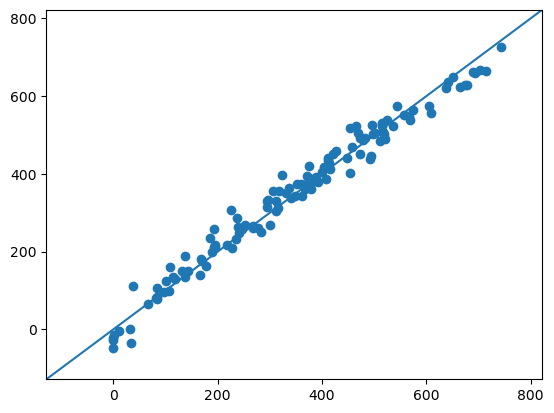

In [22]:
plt.scatter(y_eval, y_pred_eval)

y_eval_min = np.min(y_eval)
y_eval_max = np.max(y_eval)
y_pred_eval_min = np.min(y_pred_eval)
y_pred_eval_max = np.max(y_pred_eval)
y_min = np.minimum(y_eval_min, y_pred_eval_min)
y_max = np.maximum(y_eval_max, y_pred_eval_max)

y_range = y_max - y_min

lim_min = y_min - (y_range * 0.1)
lim_max = y_max + (y_range * 0.1)

plt.xlim([lim_min, lim_max])
plt.ylim([lim_min, lim_max])

plt.plot([lim_min, lim_max], [lim_min, lim_max])

plt.show()

In [23]:
mse_eval = MSE(y_eval, y_pred_eval)
rmse_eval = np.sqrt(mse_eval)

In [24]:
f"{rmse_eval=}"

'rmse_eval=np.float64(29.32974717067771)'

## 訓練済みモデルによる予測（評価用データ）

In [25]:
y_pred_test = model.predict(X_test)

In [26]:
y_pred_test

array([ 192.70745715,  318.25823008,  264.31986643,  173.09082465,
        246.00642035,  424.591786  ,  394.67491539,  239.25396139,
        426.73256418,  409.47078541,  336.69172891,  246.58500428,
        102.11201311,  330.41965022,  221.16914308,  394.81985015,
        379.93515786,  486.62083757,  293.22100425,  522.98895529,
        483.91300962,  414.82821762,  331.53490387,  213.28305136,
        390.02753348,  259.93553778,  546.1544359 ,  250.07626058,
        249.31614878,  403.51164454,  353.31948472,  584.79154672,
        387.67032029,  235.65739636,  468.42363219,  205.97900168,
        219.81051763,   99.94147192,  199.88947827,  348.97391683,
        290.59560853,  442.24893482,  462.12842877,  389.11971711,
        333.12107327,  387.50165862,  351.85234068,  375.77026742,
        269.71903587,  330.36572023,  350.51854081,  385.42978787,
        385.22621907,  412.42155995,  376.15404689,  163.31162024,
        537.22568946,  332.1749065 ,  356.77202185,  285.00803

## 採点用投稿ファイル作成

In [27]:
submit["ice_sales"] = y_pred_test

In [28]:
submit

,id,ice_sales
0,501,192.707457
1,502,318.258230
2,503,264.319866
3,504,173.090825
4,505,246.006420
...,...,...
295,796,1307.607120
296,797,1260.024776
297,798,1145.367377
298,799,1249.301998


In [29]:
submit.to_csv("submit.csv", index=False)